In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
# !wget $data

In [3]:
df = pd.read_csv('data.csv')

In [57]:
# data preparation

df.columns = df.columns.str.replace(' ', '_').str.lower()
strings = list(df.dtypes[df.dtypes == 'str'].index)
for col in strings:
    df[col] = df[col].str.replace(' ', '_').str.lower()
# df.head()

In [5]:
# # Exploratory data analysis
# for col in df.columns:
#     print(col)
#     print(df[col].unique()[:5])
#     print(df[col].nunique())
#     print(f"{df[col].isnull().sum()} null values")
#     print()

In [6]:
# sns.histplot(df.msrp, bins=50)
# sns.boxplot(df.msrp)
# sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [7]:
# price_logs = np.log1p(df.msrp)
# sns.histplot(price_logs, bins=50)

In [8]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_test - n_val

# n, n_val, n_test, n_train

In [9]:
'''Shuffle the indices'''
idx = np.arange(n)
np.random.shuffle(idx)
idx

array([5686, 1345, 7563, ..., 3316, 5821, 7426], shape=(11914,))

In [10]:
'''split the dataframe into training, validation, and testing parts'''
df_val = df.iloc[idx[:n_val]]
df_test = df.iloc[idx[n_val:n_val+n_test]]
df_train = df.iloc[idx[n_val+n_test:]]

'''reset the indexes'''
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


In [11]:
'''get y_pred and drop its corresponding column'''
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)


del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [65]:
def train_linear_regression(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)

    # weight regularisation
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [82]:
'''
    1.) Training model with base columns, i.e columns whose dtype is int.
    2.) Creating custom features from categorical columns, i.e columns whose dtype is str
'''

base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']

categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().index)
    

In [14]:
'''
    Used for model evaluation.
        The higher the number, the poorer the model
        The lower the number, the better the model
'''

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [81]:
'''
    Prepare a Dataframe for model ingestion
'''

def prepare_X(df):
    df = df.copy()
    features = base.copy()

    # Age
    df['age'] = 2017 - df.year
    features.append('age')

    # Number of doors
    for v in [2, 3, 4]:
        df[f'num_doors_{v}'] = (df.number_of_doors == v).astype(int)
        features.append(f'num_doors_{v}')

    # Categorical features
    categorical_features = {}

    for c, values in categories.items():
        for v in values:
            feature = f'{c}_{v}'
            categorical_features[feature] = (df[c] == v).astype(int)

    # Add all categorical columns at once
    df_cat = pd.DataFrame(categorical_features, index=df.index)
    
    # Select numeric/base features
    df_num = df[features]

    # Combine without repeatedly inserting columns
    df_num = pd.concat([df_num, df_cat], axis=1)

    # Handle missing values
    df_num = df_num.fillna(0)

    return df_num.values


In [69]:
'''
    Finding the optimum regularisation number
'''

for r in [0.0, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, w0, score)

0.0 5.546388775021544e+17 1.6923569333469482e+16
1e-06 282.38761429747854 1.025580852781
1e-05 2.68118965269194 0.4789573905037126
0.0001 6.071744110469125 0.46706041219843347
0.001 6.104266300813141 0.4670561765260237
0.01 6.085003479787382 0.4669416455868561
0.1 5.921040896841124 0.46600449032593677
1 5.233426694659619 0.4590664129600134
10 3.9547590209086168 0.4237835423241126
100 1.9849874170077921 0.9408081794679447
1000 0.5194049706087853 1.7878645607940702
10000 0.09518128686605751 2.024380421532935
100000 0.016216910921801712 1.7757745575637418


In [78]:
'''
    Training our Linear Regression model
'''

X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train, r=0.01)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation', rmse(y_val, y_pred))

train 0.3949444985066958
validation 0.4669416455868561


In [79]:
'''
    Testing our Linear Regression model
'''

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

X_full_train = prepare_X(df_full_train)
y_full_train = np.concatenate([y_train, y_val])

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.01)

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
print(f"test {score}")

test 0.40113901982919814


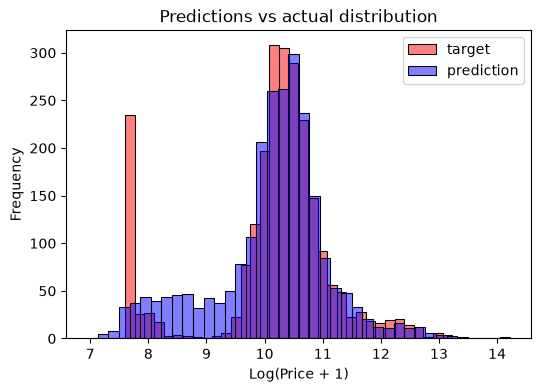

In [80]:
plt.figure(figsize=(6, 4))


sns.histplot(y_val, label='target', color='red', alpha=0.5, bins=40)
sns.histplot(y_pred, label='prediction', color='blue', alpha=0.5, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution')

plt.show()

In [86]:
# predicting the price of a car
car = df_test.iloc[1809].to_dict()
car

df_small = pd.DataFrame([car])
X_small = prepare_X(df_small)

y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(10.633344275668009)

In [88]:
actual_price = y_test[1809]
print(actual_price)

print(f"Predicted price={np.expm1(8.609825317524432)}. Actual Price={np.expm1(actual_price)}")

10.5839546799387
Predicted price=5484.290409998617. Actual Price=39495.00000000002
